# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 1.
r = 0.2

NGSOLVE = True

lc = 0.6

from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
# mesh = CleanCircle(R=R, verbosity=0, lc=lc)


In [2]:
mesh.n_triangles

99

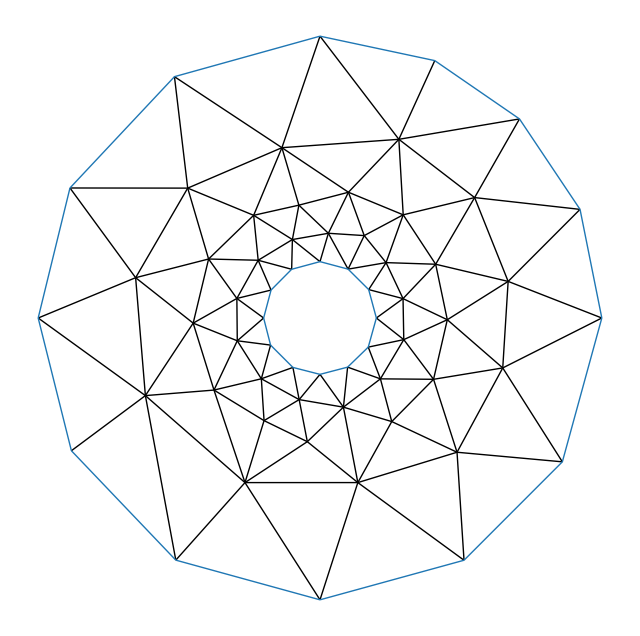

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [5]:
mesh.curve_region(Regions.SIGMA, radius=R)
mesh.curve_region(Regions.d_Omega, radius=r)


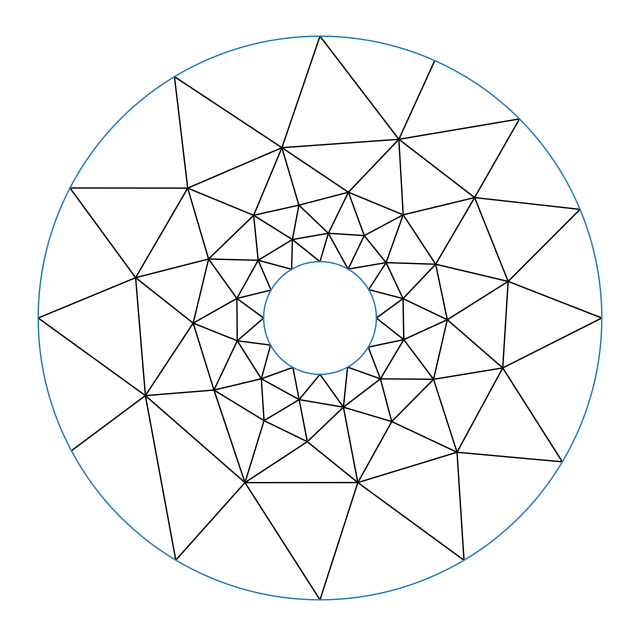

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
# boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [54]:
from trefftz.dg.assemblers import SerialNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5
numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [55]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 15
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [56]:
basis.N_DOF

1485

In [57]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [58]:
assembler._regions_RHS_term

[<Regions.d_Omega: 'd_Omega'>]

so we can set the problem:

In [59]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [ ]:
A = P.assemble_LHS()

Interior: 100%|██████████| 136/136 [00:06<00:00, 20.45edge/s]


assembling local operators
region: Sigma


100%|██████████| 13/13 [00:03<00:00,  4.11edge/s]


region: d_Omega


100%|██████████| 12/12 [00:02<00:00,  4.71edge/s]


assembling non-local operators


NtD, Sigma:  31%|███       | 4/13 [39:30<1:28:40, 591.12s/edge]

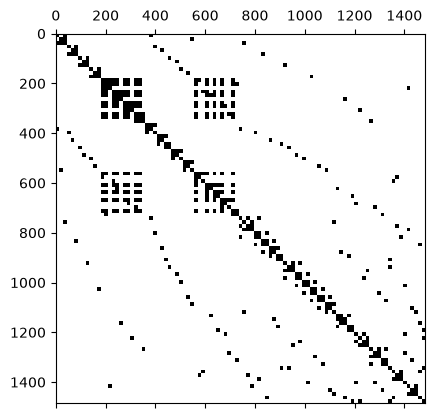

In [ ]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [ ]:
b = P.assemble_RHS()

region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.4326982178708121-0.34915890064333305j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.08653729579842317-0.2398248407406804j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.050934019307191214+0.01121398966376519j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.21898981770750903+0.1349868648260396j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.34936466634936236+0.1453021811041481j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.3288804692370881+0.16258985882953986j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.154744404458329+0.15147983452675717j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(0.01575374921680535-0.04317349634290518j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.12031801162056678-0.3518893698577517j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.5830310185357251-0.395172906464369j)
region=<Reg

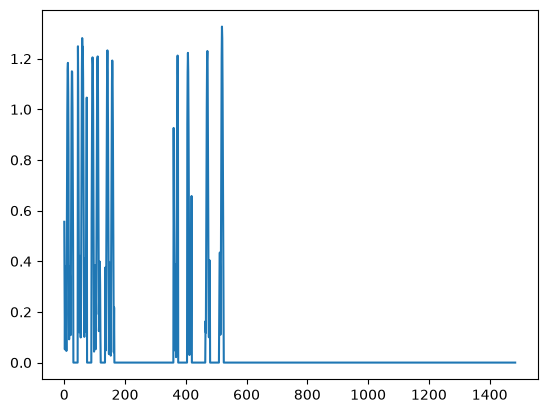

In [ ]:
import numpy as np 
plt.plot(np.abs(b))

In [ ]:
P.solve()

In [ ]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-3.78788497e+03-2.69410450e+03j,  1.61777023e+03+3.86421277e+03j,
         1.22361991e+02-3.96830945e+03j, ...,
         6.27153082e+03-1.65772510e+03j, -5.66168660e+03+1.28628880e+03j,
         5.16802236e+03+5.25439234e+02j],
       [-5.07078770e+03-4.73739772e+03j,  1.11371459e+03+4.44098040e+03j,
        -5.02438794e+02-2.20621390e+03j, ...,
         4.37869711e+03-1.12964269e+04j, -8.37696286e+03+6.72042778e+03j,
         9.00766607e+03+1.98588082e+02j],
       [ 6.47993415e+02+1.33423579e+02j, -3.69943599e+02-7.65759623e+02j,
        -3.21426039e+02+9.42901263e+02j, ...,
         4.10975471e+01-1.30819054e+02j, -1.13321743e+01-1.72921078e+02j,
        -3.24542711e+02+2.85181509e+02j],
       ...,
       [-5.42767515e+00+1.00013307e+01j,  5.00487918e+01+6.53690254e+01j,
         4.37051872e+01-1.46264129e+02j, ...,
         3.51203307e+01-1.81652330e+02j, -1.25670576e+02+2.30157993e+01j,
         1.21583452e+01+6.19027612e+01j],
       [ 1.06481328e+02+1.32997032e+02j,  1.

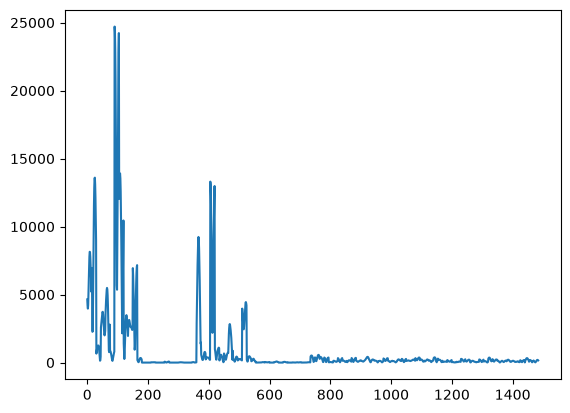

In [ ]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [ ]:
import numpy as np
# N = 200
# # rs = np.linspace(r, R, N)
# rs = np.linspace(0, R, N)

# theta = np.linspace(0, 2*np.pi, N)
# Rs, Theta = np.meshgrid(rs, theta)
# X = Rs*np.cos(Theta)
# Y = Rs*np.sin(Theta)
# x = X.ravel()
# y = Y.ravel() 
# z = P.u_h(x, y)

In [ ]:
import matplotlib.pyplot as plt
# plt.scatter(x,y,c=np.real(z),cmap="viridis")
# plt.axis("square")

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

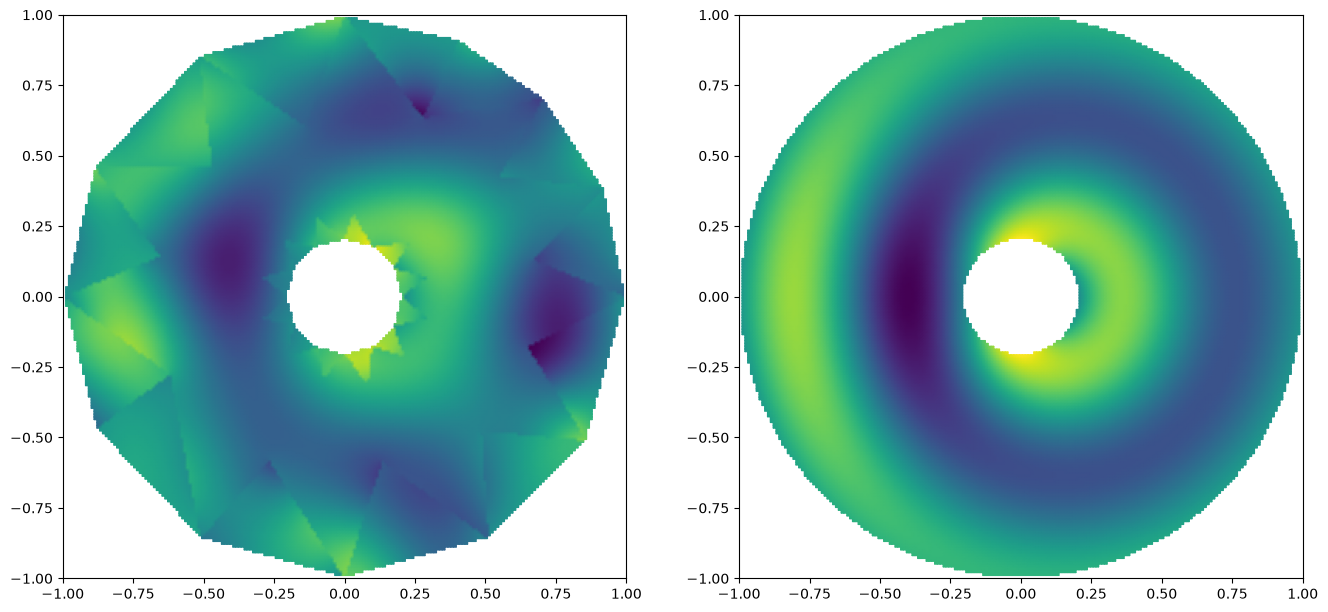

In [ ]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = P.u_h(X, Y)

RHO = np.sqrt(X**2 + Y**2)
THETA = np.arctan2(Y,X)
from scipy.special import jn, hankel1

Z_exact = sum( 1j**n*jn(n, k*r)*hankel1(n, k*RHO)/hankel1(n, k*r)*np.exp(1j*n*(THETA-np.pi)) for n in range(-50,51))
Z_exact[RHO < r ] = np.nan
Z_exact[RHO > R ] = np.nan

import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(16,8)) 
ax[0].pcolormesh(X, Y, np.real(Z), shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(Z_exact), shading="gouraud")
ax[1].axis('square')